import libraries

In [2]:
import random
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

ImageFile.LOAD_TRUNCATED_IMAGES = True


config

In [4]:
PROJECT_ROOT = Path("..")

TRAIN_DIR = (
    PROJECT_ROOT
    / "data"
    / "Epic and CSCR hospital Dataset"
    / "train"
)

TEST_DIR = (
    PROJECT_ROOT
    / "data"
    / "Epic and CSCR hospital Dataset"
    / "test"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_PATH = (
    OUTPUT_DIR
    / "best_brain_tumor_cnn.pth"
)

HISTORY_PATH = (
    OUTPUT_DIR
    / "training_history.csv"
)

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "test_predictions.csv"
)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20

LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

VALIDATION_SIZE = 0.15
EARLY_STOPPING_PATIENCE = 5

CONFIDENCE_THRESHOLD = 0.70
RANDOM_SEED = 42

NUM_WORKERS = 0

SUPPORTED_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
}

print("Training directory:", TRAIN_DIR.resolve())
print("Test directory:", TEST_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Training directory: /Users/ra20549220/Desktop/ML/BrainTumorMRIClassification/data/Epic and CSCR hospital Dataset/train
Test directory: /Users/ra20549220/Desktop/ML/BrainTumorMRIClassification/data/Epic and CSCR hospital Dataset/test
Output directory: /Users/ra20549220/Desktop/ML/BrainTumorMRIClassification/outputs


Set Seed and Select Device

In [5]:


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Dataset directories found successfully.")
print("Selected device:", device)

Dataset directories found successfully.
Selected device: mps


Dataset Preparation

Create Training and Test DataFrames

In [6]:
def create_image_dataframe(directory):
    image_records = []

    class_directories = sorted(
        [
            folder
            for folder in directory.iterdir()
            if folder.is_dir()
            and not folder.name.startswith(".")
        ]
    )

    for class_directory in class_directories:
        class_name = class_directory.name

        for image_path in class_directory.rglob("*"):
            if (
                image_path.is_file()
                and image_path.suffix.lower()
                in SUPPORTED_EXTENSIONS
            ):
                image_records.append(
                    {
                        "image_path": str(image_path),
                        "class_name": class_name
                    }
                )

    dataframe = pd.DataFrame(
        image_records
    )

    if dataframe.empty:
        raise ValueError(
            f"No supported images found in {directory.resolve()}"
        )

    return dataframe


train_full_df = create_image_dataframe(
    TRAIN_DIR
)

test_df = create_image_dataframe(
    TEST_DIR
)

print("Provided training images:", len(train_full_df))
print("Provided testing images:", len(test_df))

display(train_full_df.head())

Provided training images: 9291
Provided testing images: 1857


,image_path,class_name
0,../data/Epic and CSCR hospital Dataset/train/g...,glioma
1,../data/Epic and CSCR hospital Dataset/train/g...,glioma
2,../data/Epic and CSCR hospital Dataset/train/g...,glioma
3,../data/Epic and CSCR hospital Dataset/train/g...,glioma
4,../data/Epic and CSCR hospital Dataset/train/g...,glioma


Basic Dataset Checks

In [7]:
print("Training dataframe shape:", train_full_df.shape)
print("Testing dataframe shape:", test_df.shape)

print("\nTraining missing values:")
print(train_full_df.isnull().sum())

print("\nTesting missing values:")
print(test_df.isnull().sum())

print(
    "\nDuplicate training paths:",
    train_full_df["image_path"]
    .duplicated()
    .sum()
)

print(
    "Duplicate testing paths:",
    test_df["image_path"]
    .duplicated()
    .sum()
)

train_classes = sorted(
    train_full_df["class_name"]
    .unique()
    .tolist()
)

test_classes = sorted(
    test_df["class_name"]
    .unique()
    .tolist()
)

print("\nTraining classes:", train_classes)
print("Testing classes:", test_classes)

if train_classes != test_classes:
    raise ValueError(
        "Training and testing folders contain different classes."
    )

class_names = train_classes

class_to_index = {
    class_name: index
    for index, class_name
    in enumerate(class_names)
}

index_to_class = {
    index: class_name
    for class_name, index
    in class_to_index.items()
}

num_classes = len(class_names)

print("\nClass mapping:", class_to_index)
print("Number of classes:", num_classes)


Training dataframe shape: (9291, 2)
Testing dataframe shape: (1857, 2)

Training missing values:
image_path    0
class_name    0
dtype: int64

Testing missing values:
image_path    0
class_name    0
dtype: int64

Duplicate training paths: 0
Duplicate testing paths: 0

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Number of classes: 4


Visualize Class Distribution

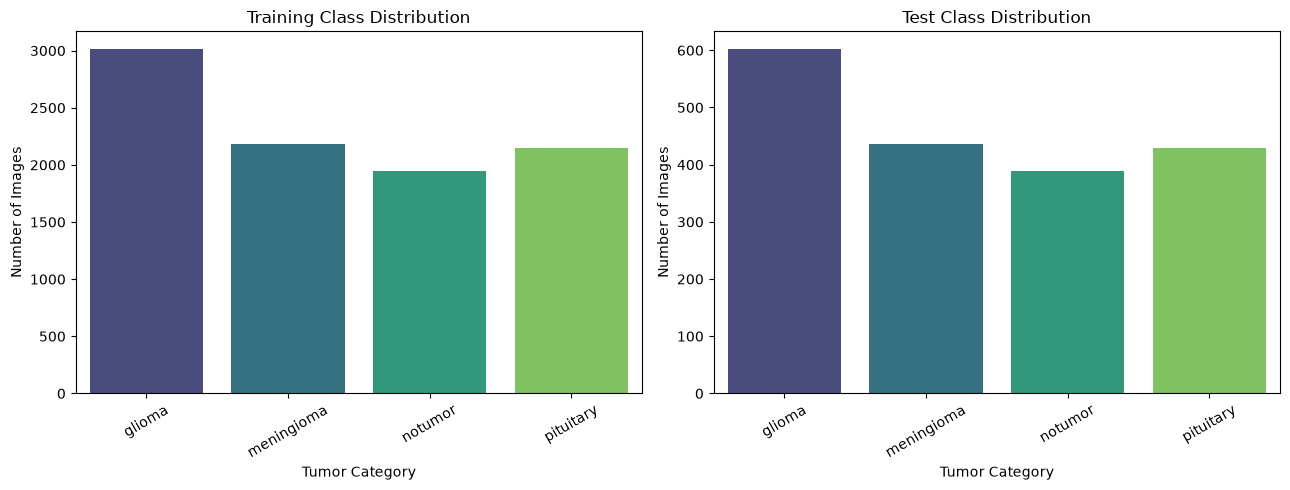

In [8]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

train_order = (
    train_full_df["class_name"]
    .value_counts()
    .reindex(class_names)
)

test_order = (
    test_df["class_name"]
    .value_counts()
    .reindex(class_names)
)

sns.barplot(
    x=train_order.index,
    y=train_order.values,
    hue=train_order.index,
    palette="viridis",
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Training Class Distribution"
)
axes[0].set_xlabel("Tumor Category")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(
    axis="x",
    rotation=30
)

sns.barplot(
    x=test_order.index,
    y=test_order.values,
    hue=test_order.index,
    palette="viridis",
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Test Class Distribution"
)
axes[1].set_xlabel("Tumor Category")
axes[1].set_ylabel("Number of Images")
axes[1].tick_params(
    axis="x",
    rotation=30
)

plt.tight_layout()
plt.show()

Display Sample MRI Images

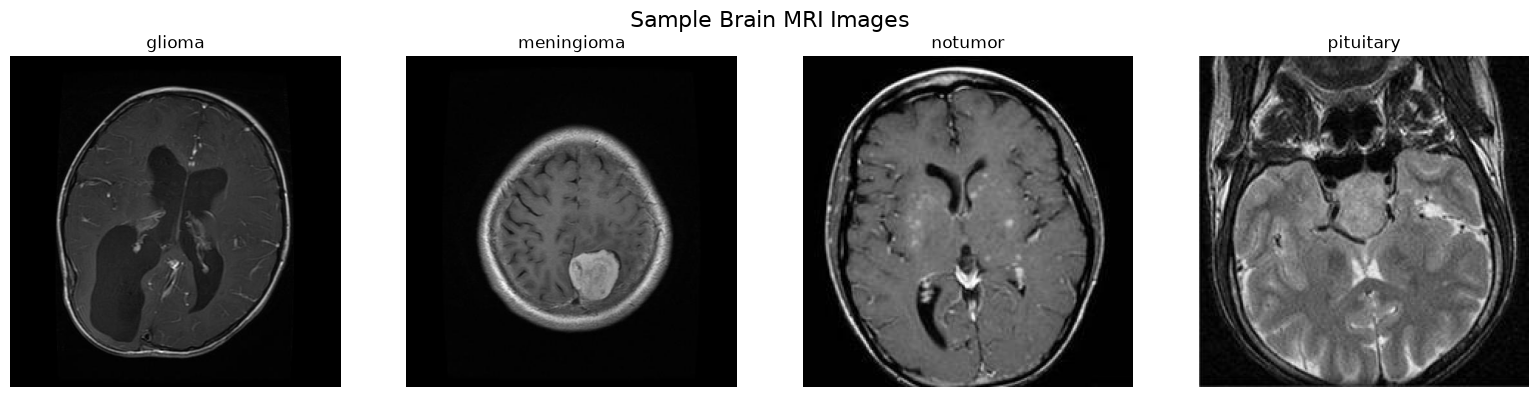

In [9]:
fig, axes = plt.subplots(
    1,
    num_classes,
    figsize=(4 * num_classes, 4)
)

if num_classes == 1:
    axes = [axes]

for axis, class_name in zip(
    axes,
    class_names
):
    class_dataframe = train_full_df[
        train_full_df["class_name"]
        == class_name
    ]

    sample_path = (
        class_dataframe
        .sample(
            n=1,
            random_state=RANDOM_SEED
        )
        ["image_path"]
        .iloc[0]
    )

    with Image.open(sample_path) as image:
        sample_image = image.convert("RGB")

    axis.imshow(sample_image)
    axis.set_title(class_name)
    axis.axis("off")

plt.suptitle(
    "Sample Brain MRI Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

Create Training and Validation Splits

In [10]:
train_df, validation_df = train_test_split(
    train_full_df,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_SEED,
    stratify=train_full_df["class_name"]
)

train_df = train_df.reset_index(
    drop=True
)

validation_df = validation_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))
print("Testing images:", len(test_df))

split_distribution = pd.concat(
    [
        train_df["class_name"]
        .value_counts()
        .rename("Training"),

        validation_df["class_name"]
        .value_counts()
        .rename("Validation"),

        test_df["class_name"]
        .value_counts()
        .rename("Testing")
    ],
    axis=1
).fillna(0).astype(int)

display(
    split_distribution
    .reindex(class_names)
)

Training images: 7897
Validation images: 1394
Testing images: 1857


,Training,Validation,Testing
class_name,,,
glioma,2565,453,603
meningioma,1856,327,436
notumor,1653,292,389
pituitary,1823,322,429


Image Preprocessing

Data augmentation is used only for the training set.

In [11]:
train_transforms = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.RandomHorizontalFlip(
            p=0.5
        ),
        transforms.RandomRotation(
            degrees=10
        ),
        transforms.RandomAffine(
            degrees=0,
            translate=(0.05, 0.05),
            scale=(0.95, 1.05)
        ),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )
    ]
)

evaluation_transforms = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.5, 0.5, 0.5],
            std=[0.5, 0.5, 0.5]
        )
    ]
)

print("Image transformations created.")

Image transformations created.


Create Custom Dataset

In [12]:
class BrainTumorDataset(Dataset):
    def __init__(
        self,
        dataframe,
        class_to_index,
        transform=None
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.class_to_index = (
            class_to_index
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        class_name = row["class_name"]

        try:
            with Image.open(
                image_path
            ) as image:
                image = image.convert("RGB")

                if self.transform is not None:
                    image = self.transform(image)

        except Exception as error:
            raise RuntimeError(
                f"Unable to load image: {image_path}"
            ) from error

        label = self.class_to_index[
            class_name
        ]

        return image, label

Create Datasets and DataLoaders

In [13]:
train_dataset = BrainTumorDataset(
    dataframe=train_df,
    class_to_index=class_to_index,
    transform=train_transforms
)

validation_dataset = BrainTumorDataset(
    dataframe=validation_df,
    class_to_index=class_to_index,
    transform=evaluation_transforms
)

test_dataset = BrainTumorDataset(
    dataframe=test_df,
    class_to_index=class_to_index,
    transform=evaluation_transforms
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

sample_images, sample_labels = next(
    iter(train_loader)
)

print(
    "Image batch shape:",
    sample_images.shape
)

print(
    "Label batch shape:",
    sample_labels.shape
)

print(
    "Image data type:",
    sample_images.dtype
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Training batches: 247
Validation batches: 44
Testing batches: 59


CNN Model

Define and Initialize CNN

In [14]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=256,
                out_features=128
            ),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(
                in_features=128,
                out_features=num_classes
            )
        )

    def forward(self, images):
        features = self.features(images)
        logits = self.classifier(features)

        return logits


model = BrainTumorCNN(
    num_classes=num_classes
).to(device)

print(model)

print(
    "Model device:",
    next(model.parameters()).device
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)

BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, a

Verify Model Output

In [15]:
verification_images, verification_labels = next(
    iter(train_loader)
)

verification_images = verification_images.to(
    device
)

model.eval()

with torch.no_grad():
    verification_logits = model(
        verification_images
    )

print(
    "Input shape:",
    verification_images.shape
)

print(
    "Output shape:",
    verification_logits.shape
)

print(
    "Number of classes:",
    num_classes
)

assert verification_logits.shape == (
    verification_images.size(0),
    num_classes
)

print("Model output verification passed.")

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 4])
Number of classes: 4
Model output verification passed.


Training Configuration

Configure Loss, Optimizer and Scheduler

Class weights give more importance to classes with fewer training images.

In [16]:
class_counts = (
    train_df["class_name"]
    .value_counts()
    .reindex(class_names)
)

class_weights = (
    len(train_df)
    / (
        num_classes
        * class_counts.values
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

class_weight_df = pd.DataFrame(
    {
        "class_name": class_names,
        "training_images": (
            class_counts.values
        ),
        "class_weight": class_weights
    }
)

display(class_weight_df)

print(
    "Loss function:",
    criterion
)

print(
    "Optimizer:",
    optimizer.__class__.__name__
)

print(
    "Initial learning rate:",
    LEARNING_RATE
)

,class_name,training_images,class_weight
0,glioma,2565,0.769688
1,meningioma,1856,1.063712
2,notumor,1653,1.194344
3,pituitary,1823,1.082968


Loss function: CrossEntropyLoss()
Optimizer: AdamW
Initial learning rate: 0.001


Define Training Function

In [17]:
def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    progress_bar = tqdm(
        data_loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)
        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        current_batch_size = images.size(0)

        total_loss += (
            loss.item()
            * current_batch_size
        )

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_samples += (
            current_batch_size
        )

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = (
        total_loss
        / total_samples
    )

    epoch_accuracy = (
        correct_predictions
        / total_samples
    )

    return epoch_loss, epoch_accuracy


Define Evaluation Function

In [18]:
def evaluate_model(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in tqdm(
            data_loader,
            desc="Evaluating",
            leave=False
        ):
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            current_batch_size = images.size(0)

            total_loss += (
                loss.item()
                * current_batch_size
            )

            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_samples += (
                current_batch_size
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    epoch_loss = (
        total_loss
        / total_samples
    )

    epoch_accuracy = (
        correct_predictions
        / total_samples
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "labels": np.array(
            all_labels
        ),
        "predictions": np.array(
            all_predictions
        ),
        "probabilities": np.array(
            all_probabilities
        )
    }

Train Model With Early Stopping

In [19]:
history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": [],
    "learning_rate": []
}

best_validation_loss = float("inf")

best_model_weights = copy.deepcopy(
    model.state_dict()
)

epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(
    1,
    NUM_EPOCHS + 1
):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    validation_results = evaluate_model(
        model=model,
        data_loader=validation_loader,
        criterion=criterion,
        device=device
    )

    validation_loss = (
        validation_results["loss"]
    )

    validation_accuracy = (
        validation_results["accuracy"]
    )

    scheduler.step(
        validation_loss
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    history["train_loss"].append(
        train_loss
    )

    history["validation_loss"].append(
        validation_loss
    )

    history["train_accuracy"].append(
        train_accuracy
    )

    history["validation_accuracy"].append(
        validation_accuracy
    )

    history["learning_rate"].append(
        current_learning_rate
    )

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"Learning Rate: {current_learning_rate:.6f}"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss

        best_model_weights = copy.deepcopy(
            model.state_dict()
        )

        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": (
                    best_model_weights
                ),
                "class_to_index": (
                    class_to_index
                ),
                "image_size": IMAGE_SIZE,
                "best_validation_loss": (
                    best_validation_loss
                ),
                "best_epoch": epoch
            },
            MODEL_PATH
        )

        print("Best model saved.")

    else:
        epochs_without_improvement += 1

        print(
            "Epochs without improvement:",
            epochs_without_improvement
        )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print("Early stopping activated.")
        break

training_duration = (
    time.time()
    - training_start_time
)

model.load_state_dict(
    best_model_weights
)

history_df = pd.DataFrame(
    history
)

history_df.insert(
    0,
    "epoch",
    range(
        1,
        len(history_df) + 1
    )
)

history_df.to_csv(
    HISTORY_PATH,
    index=False
)

print(
    "\nTraining time in minutes:",
    round(
        training_duration / 60,
        2
    )
)

print(
    "Best validation loss:",
    round(
        best_validation_loss,
        4
    )
)

print(
    "Saved model:",
    MODEL_PATH.resolve()
)

Training:   0%|          | 0/247 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.0023 | Validation Loss: 0.8044 | Train Accuracy: 0.5822 | Validation Accuracy: 0.6750 | Learning Rate: 0.001000
Best model saved.


Training:   0%|          | 0/247 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 0.3465 | Validation Loss: 0.3912 | Train Accuracy: 0.8706 | Validation Accuracy: 0.8659 | Learning Rate: 0.000250
Epochs without improvement: 3


Training:   0%|          | 0/247 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/44 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 0.3056 | Validation Loss: 0.3940 | Train Accuracy: 0.8850 | Validation Accuracy: 0.8486 | Learning Rate: 0.000250
Epochs without improvement: 4

Training time in minutes: 81.86
Best validation loss: 0.2897
Saved model: /Users/ra20549220/Desktop/ML/BrainTumorMRIClassification/outputs/best_brain_tumor_cnn.pth


Training Evaluation

Plot Training History

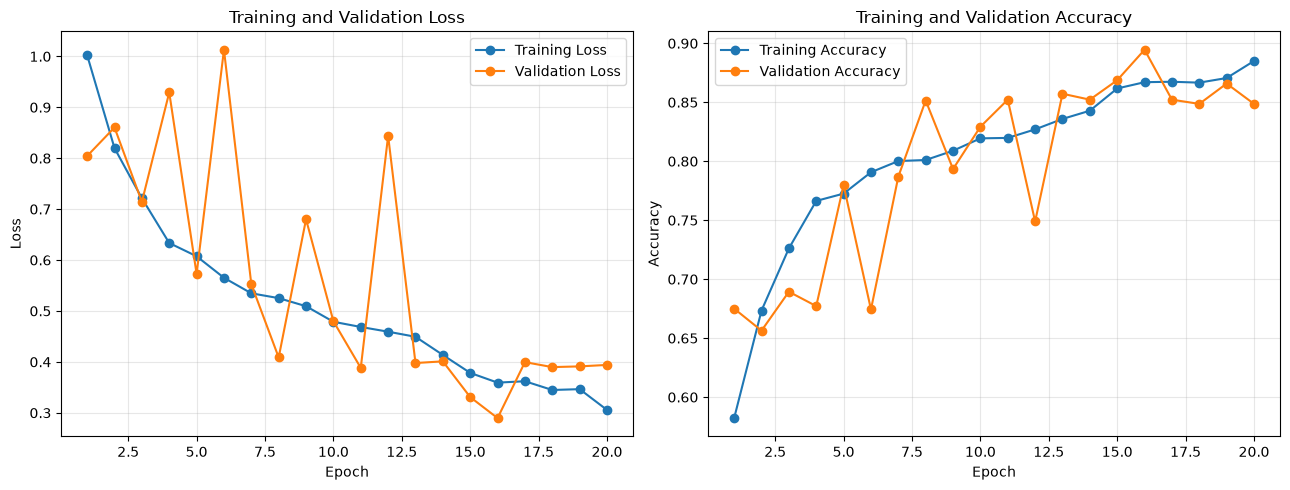

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

axes[0].plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation Loss"
)

axes[0].set_title(
    "Training and Validation Loss"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

axes[1].plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

axes[1].set_title(
    "Training and Validation Accuracy"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Final Test Evaluation

Load Best Model and Evaluate Test Set

In [21]:
checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

test_labels = (
    test_results["labels"]
)

test_predictions = (
    test_results["predictions"]
)

test_probabilities = (
    test_results["probabilities"]
)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _
) = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _
) = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print(
    "Best checkpoint epoch:",
    checkpoint["best_epoch"]
)

print(
    "Test loss:",
    round(
        test_results["loss"],
        4
    )
)

print(
    "Test accuracy:",
    round(
        test_results["accuracy"],
        4
    )
)

print(
    "Macro precision:",
    round(
        macro_precision,
        4
    )
)

print(
    "Macro recall:",
    round(
        macro_recall,
        4
    )
)

print(
    "Macro F1-score:",
    round(
        macro_f1,
        4
    )
)

print(
    "Weighted F1-score:",
    round(
        weighted_f1,
        4
    )
)

Evaluating:   0%|          | 0/59 [00:00<?, ?it/s]

Best checkpoint epoch: 16
Test loss: 0.4591
Test accuracy: 0.8298
Macro precision: 0.8382
Macro recall: 0.8499
Macro F1-score: 0.8366
Weighted F1-score: 0.8283


Classification Report

In [22]:
report = classification_report(
    test_labels,
    test_predictions,
    labels=list(
        range(num_classes)
    ),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report
).transpose()

display(
    report_df.round(4)
)

,precision,recall,f1-score,support
glioma,0.9201,0.6683,0.7743,603.0000
meningioma,0.6438,0.7752,0.7034,436.0000
notumor,0.8819,0.9794,0.9281,389.0000
pituitary,0.9069,0.9767,0.9405,429.0000
accuracy,0.8298,0.8298,0.8298,0.8298
macro avg,0.8382,0.8499,0.8366,1857.0000
weighted avg,0.8442,0.8298,0.8283,1857.0000


Confusion Matrix

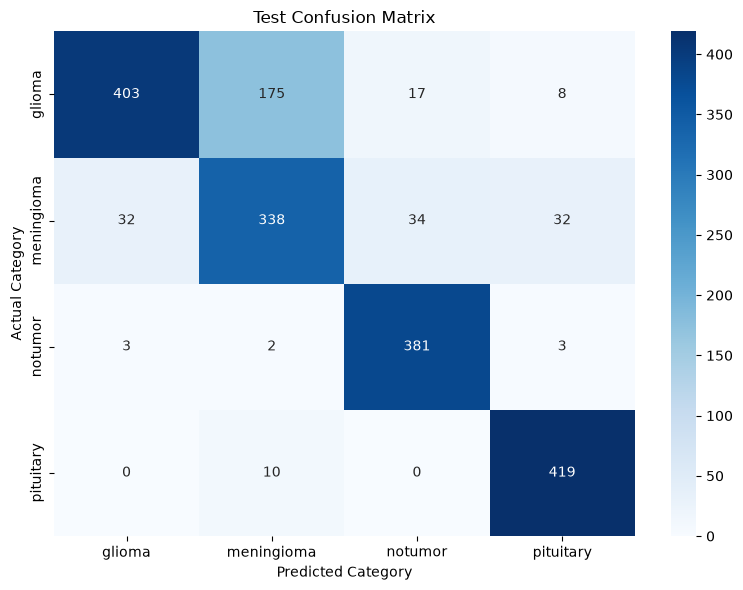

In [23]:
confusion_matrix_values = confusion_matrix(
    test_labels,
    test_predictions,
    labels=list(
        range(num_classes)
    )
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Category"
)

plt.ylabel(
    "Actual Category"
)

plt.tight_layout()
plt.show()


Prediction Analysis

Create Test Prediction Results

In [24]:
prediction_confidences = (
    test_probabilities.max(
        axis=1
    )
)

prediction_results_df = pd.DataFrame(
    {
        "image_path": (
            test_df["image_path"].values
        ),
        "actual_label": test_labels,
        "predicted_label": (
            test_predictions
        ),
        "actual_class": [
            index_to_class[int(label)]
            for label in test_labels
        ],
        "predicted_class": [
            index_to_class[int(label)]
            for label in test_predictions
        ],
        "confidence": (
            prediction_confidences
        )
    }
)

prediction_results_df[
    "is_correct"
] = (
    prediction_results_df["actual_label"]
    == prediction_results_df[
        "predicted_label"
    ]
)

prediction_results_df[
    "requires_review"
] = (
    prediction_results_df["confidence"]
    < CONFIDENCE_THRESHOLD
)

prediction_results_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

correct_count = int(
    prediction_results_df[
        "is_correct"
    ].sum()
)

incorrect_count = int(
    (
        prediction_results_df[
            "is_correct"
        ]
        == False
    ).sum()
)

low_confidence_count = int(
    prediction_results_df[
        "requires_review"
    ].sum()
)

print(
    "Total test images:",
    len(prediction_results_df)
)

print(
    "Correct predictions:",
    correct_count
)

print(
    "Incorrect predictions:",
    incorrect_count
)

print(
    "Low-confidence predictions:",
    low_confidence_count
)

display(
    prediction_results_df.head()
)

Total test images: 1857
Correct predictions: 1541
Incorrect predictions: 316
Low-confidence predictions: 238


,image_path,actual_label,predicted_label,actual_class,predicted_class,confidence,is_correct,requires_review
0,../data/Epic and CSCR hospital Dataset/test/gl...,0,0,glioma,glioma,0.999859,True,False
1,../data/Epic and CSCR hospital Dataset/test/gl...,0,0,glioma,glioma,0.999318,True,False
2,../data/Epic and CSCR hospital Dataset/test/gl...,0,0,glioma,glioma,0.878452,True,False
3,../data/Epic and CSCR hospital Dataset/test/gl...,0,1,glioma,meningioma,0.942290,False,False
4,../data/Epic and CSCR hospital Dataset/test/gl...,0,0,glioma,glioma,0.928085,True,False


Display Misclassified Images

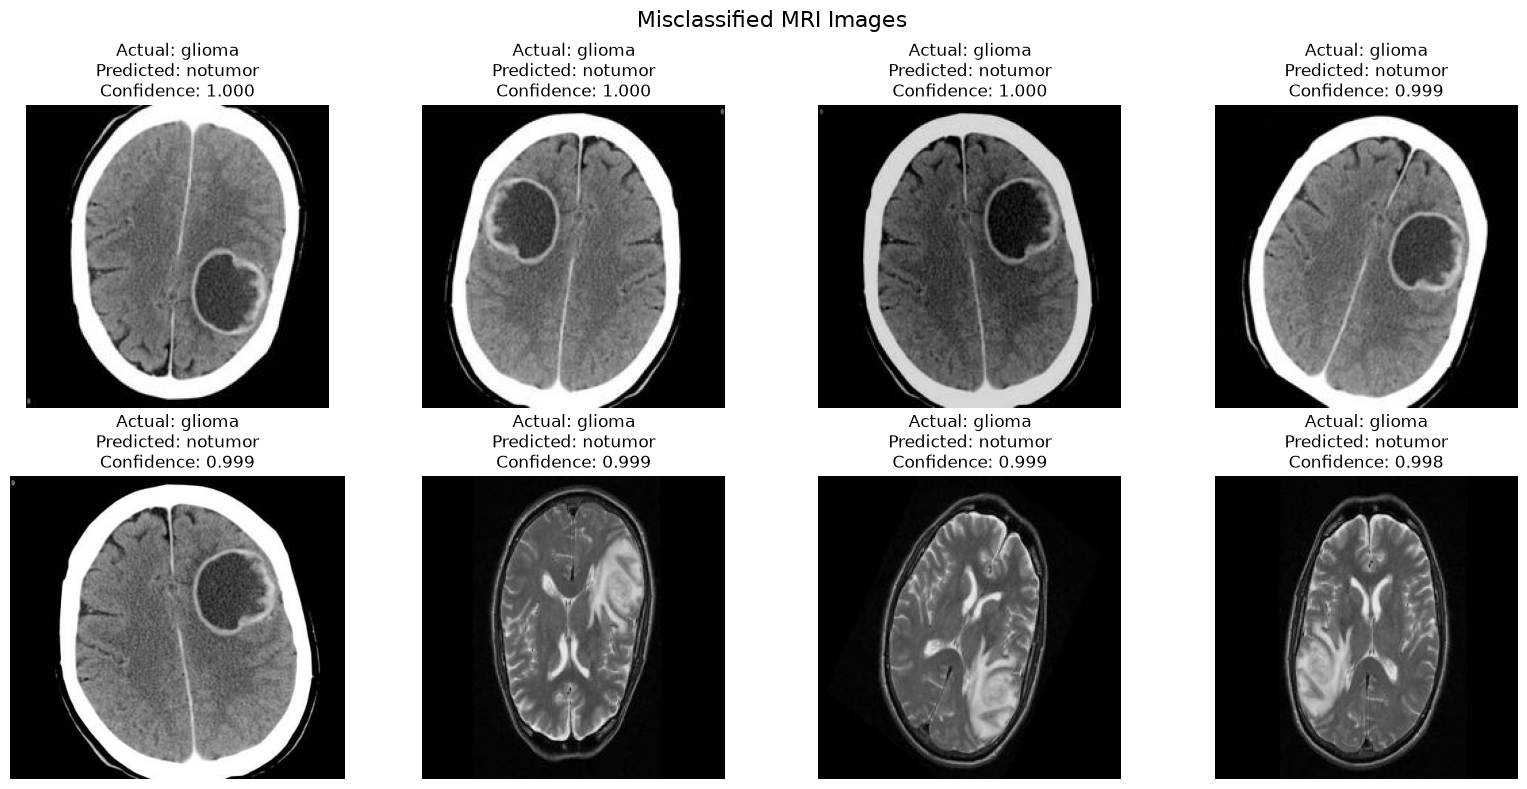

In [25]:
misclassified_df = (
    prediction_results_df[
        prediction_results_df[
            "is_correct"
        ]
        == False
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
    .head(8)
)

if misclassified_df.empty:
    print(
        "No misclassified test images."
    )

else:
    number_of_images = len(
        misclassified_df
    )

    number_of_columns = 4

    number_of_rows = int(
        np.ceil(
            number_of_images
            / number_of_columns
        )
    )

    fig, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(
            16,
            4 * number_of_rows
        )
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for index, row in enumerate(
        misclassified_df.itertuples()
    ):
        with Image.open(
            row.image_path
        ) as image:
            display_image = (
                image.convert("RGB")
            )

        axes[index].imshow(
            display_image
        )

        axes[index].set_title(
            f"Actual: {row.actual_class}\n"
            f"Predicted: {row.predicted_class}\n"
            f"Confidence: {row.confidence:.3f}"
        )

        axes[index].axis("off")

    for index in range(
        number_of_images,
        len(axes)
    ):
        axes[index].axis("off")

    plt.suptitle(
        "Misclassified MRI Images",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

Single-Image Inference

Define Prediction Function

In [26]:
def predict_image(
    image_path,
    model,
    transform,
    class_names,
    device,
    confidence_threshold=0.70
):
    image_path = Path(
        image_path
    )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {image_path.resolve()}"
        )

    with Image.open(
        image_path
    ) as image:
        original_image = (
            image.convert("RGB")
        )

    input_tensor = (
        transform(original_image)
        .unsqueeze(0)
        .to(device)
    )

    model.eval()

    with torch.no_grad():
        logits = model(
            input_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    confidence, predicted_index = torch.max(
        probabilities,
        dim=0
    )

    predicted_index = int(
        predicted_index.item()
    )

    confidence = float(
        confidence.item()
    )

    class_probabilities = {
        class_name: float(
            probabilities[
                class_index
            ].item()
        )
        for class_index, class_name
        in enumerate(class_names)
    }

    requires_review = (
        confidence
        < confidence_threshold
    )

    return {
        "predicted_class": (
            class_names[
                predicted_index
            ]
        ),
        "confidence": confidence,
        "requires_review": (
            requires_review
        ),
        "class_probabilities": (
            class_probabilities
        ),
        "original_image": (
            original_image
        )
    }

Test Single-Image Prediction

Image path: ../data/Epic and CSCR hospital Dataset/test/glioma/1353.jpg
Predicted class: glioma
Confidence: 0.9999
Manual review recommended: False

Class probabilities:
glioma: 0.9999
notumor: 0.0001
meningioma: 0.0000
pituitary: 0.0000


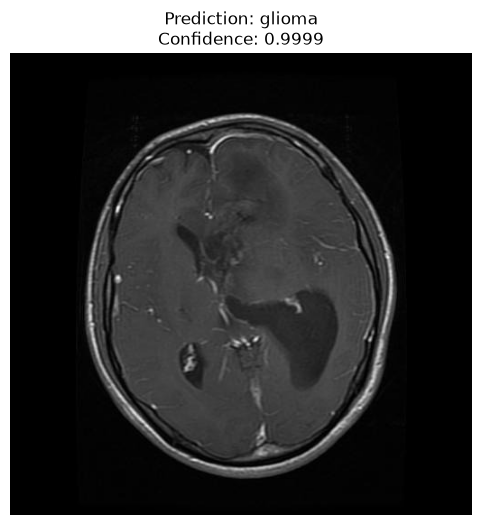

In [27]:
sample_image_path = (
    test_df.iloc[0][
        "image_path"
    ]
)

prediction_result = predict_image(
    image_path=sample_image_path,
    model=model,
    transform=evaluation_transforms,
    class_names=class_names,
    device=device,
    confidence_threshold=(
        CONFIDENCE_THRESHOLD
    )
)

print(
    "Image path:",
    sample_image_path
)

print(
    "Predicted class:",
    prediction_result[
        "predicted_class"
    ]
)

print(
    "Confidence:",
    round(
        prediction_result[
            "confidence"
        ],
        4
    )
)

print(
    "Manual review recommended:",
    prediction_result[
        "requires_review"
    ]
)

print("\nClass probabilities:")

sorted_probabilities = sorted(
    prediction_result[
        "class_probabilities"
    ].items(),
    key=lambda item: item[1],
    reverse=True
)

for class_name, probability in sorted_probabilities:
    print(
        f"{class_name}: "
        f"{probability:.4f}"
    )

plt.figure(
    figsize=(6, 6)
)

plt.imshow(
    prediction_result[
        "original_image"
    ]
)

plt.title(
    f"Prediction: "
    f"{prediction_result['predicted_class']}\n"
    f"Confidence: "
    f"{prediction_result['confidence']:.4f}"
)

plt.axis("off")
plt.show()


Verify Saved Model Loading

In [28]:
saved_checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

saved_class_to_index = (
    saved_checkpoint[
        "class_to_index"
    ]
)

saved_class_names = [
    class_name
    for class_name, class_index
    in sorted(
        saved_class_to_index.items(),
        key=lambda item: item[1]
    )
]

loaded_model = BrainTumorCNN(
    num_classes=len(
        saved_class_names
    )
).to(device)

loaded_model.load_state_dict(
    saved_checkpoint[
        "model_state_dict"
    ]
)

loaded_model.eval()

print(
    "Saved model loaded successfully."
)

print(
    "Saved classes:",
    saved_class_names
)

print(
    "Best epoch:",
    saved_checkpoint[
        "best_epoch"
    ]
)

print(
    "Best validation loss:",
    round(
        saved_checkpoint[
            "best_validation_loss"
        ],
        4
    )
)

print(
    "Loaded model device:",
    next(
        loaded_model.parameters()
    ).device
)

Saved model loaded successfully.
Saved classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Best epoch: 16
Best validation loss: 0.2897
Loaded model device: mps:0


Improved HPT config

In [29]:
IMPROVED_HPT_EPOCHS = 20
IMPROVED_HPT_PATIENCE = 5

IMPROVED_HPT_MODEL_PATH = (
    OUTPUT_DIR
    / "best_improved_tuned_cnn.pth"
)

improved_hpt_configs = [
    {
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
        "dropout": 0.40
    },
    {
        "learning_rate": 0.0007,
        "weight_decay": 0.0001,
        "dropout": 0.40
    },
    {
        "learning_rate": 0.001,
        "weight_decay": 0.0005,
        "dropout": 0.45
    }
]

print(
    "Improved HPT trials:",
    len(improved_hpt_configs)
)

Improved HPT trials: 3


Evaluation Function With Macro F1

In [30]:
def evaluate_for_hpt(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(
                logits,
                labels
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            predictions = torch.argmax(
                probabilities,
                dim=1
            )

            current_batch_size = images.size(0)

            total_loss += (
                loss.item()
                * current_batch_size
            )

            total_samples += (
                current_batch_size
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    labels_array = np.array(
        all_labels
    )

    predictions_array = np.array(
        all_predictions
    )

    probabilities_array = np.array(
        all_probabilities
    )

    accuracy = (
        labels_array
        == predictions_array
    ).mean()

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels_array,
            predictions_array,
            average="macro",
            zero_division=0
        )
    )

    return {
        "loss": (
            total_loss
            / total_samples
        ),
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "labels": labels_array,
        "predictions": predictions_array,
        "probabilities": probabilities_array
    }

Improved HPT Trial Function

This version selects the best checkpoint using validation macro F1, which better reflects balanced performance across all four classes.

In [31]:
def run_improved_hpt_trial(
    config,
    trial_number
):
    set_seed(
        RANDOM_SEED
        + trial_number
    )

    trial_model = BrainTumorCNN(
        num_classes=num_classes,
        dropout=config["dropout"]
    ).to(device)

    trial_criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor
    )

    trial_optimizer = optim.AdamW(
        trial_model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    trial_scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            trial_optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )

    best_validation_f1 = -1.0
    best_validation_loss = float("inf")
    best_validation_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    epochs_without_improvement = 0
    trial_history = []

    print()
    print("=" * 65)
    print(
        f"Starting improved HPT trial "
        f"{trial_number}"
    )
    print(config)
    print("=" * 65)

    for epoch in range(
        1,
        IMPROVED_HPT_EPOCHS + 1
    ):
        train_loss, train_accuracy = train_one_epoch(
            model=trial_model,
            data_loader=train_loader,
            criterion=trial_criterion,
            optimizer=trial_optimizer,
            device=device
        )

        validation_results = evaluate_for_hpt(
            model=trial_model,
            data_loader=validation_loader,
            criterion=trial_criterion,
            device=device
        )

        validation_loss = (
            validation_results["loss"]
        )

        validation_accuracy = (
            validation_results["accuracy"]
        )

        validation_macro_f1 = (
            validation_results["macro_f1"]
        )

        trial_scheduler.step(
            validation_macro_f1
        )

        current_learning_rate = (
            trial_optimizer
            .param_groups[0]["lr"]
        )

        trial_history.append(
            {
                "trial": trial_number,
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "validation_loss": validation_loss,
                "validation_accuracy": (
                    validation_accuracy
                ),
                "validation_macro_f1": (
                    validation_macro_f1
                ),
                "learning_rate": (
                    current_learning_rate
                )
            }
        )

        print(
            f"Trial {trial_number} | "
            f"Epoch {epoch:02d}/"
            f"{IMPROVED_HPT_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Validation Accuracy: "
            f"{validation_accuracy:.4f} | "
            f"Validation Macro F1: "
            f"{validation_macro_f1:.4f}"
        )

        minimum_improvement = 0.001

        if (
            validation_macro_f1
            > best_validation_f1
            + minimum_improvement
        ):
            best_validation_f1 = (
                validation_macro_f1
            )

            best_validation_loss = (
                validation_loss
            )

            best_validation_accuracy = (
                validation_accuracy
            )

            best_model_state = copy.deepcopy(
                trial_model.state_dict()
            )

            best_epoch = epoch
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= IMPROVED_HPT_PATIENCE
        ):
            print(
                f"Trial {trial_number} "
                f"stopped at epoch {epoch}."
            )
            break

    return {
        "trial": trial_number,
        "learning_rate": (
            config["learning_rate"]
        ),
        "weight_decay": (
            config["weight_decay"]
        ),
        "dropout": config["dropout"],
        "best_epoch": best_epoch,
        "best_validation_loss": (
            best_validation_loss
        ),
        "best_validation_accuracy": (
            best_validation_accuracy
        ),
        "best_validation_macro_f1": (
            best_validation_f1
        ),
        "model_state_dict": (
            best_model_state
        ),
        "history": trial_history
    }

Replace the CNN class

In [34]:
class BrainTumorCNN(nn.Module):
    def __init__(
        self,
        num_classes,
        dropout=0.40
    ):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            nn.AdaptiveAvgPool2d(
                output_size=(1, 1)
            )
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                in_features=256,
                out_features=128
            ),
            nn.ReLU(),
            nn.Dropout(
                p=dropout
            ),
            nn.Linear(
                in_features=128,
                out_features=num_classes
            )
        )

    def forward(self, images):
        features = self.features(images)
        logits = self.classifier(features)

        return logits


print("Updated BrainTumorCNN class defined successfully.")

Updated BrainTumorCNN class defined successfully.


HPT

In [35]:
improved_hpt_results = []

improved_hpt_start_time = time.time()

for trial_number, config in enumerate(
    improved_hpt_configs,
    start=1
):
    trial_result = run_improved_hpt_trial(
        config=config,
        trial_number=trial_number
    )

    improved_hpt_results.append(
        trial_result
    )

improved_hpt_duration = (
    time.time()
    - improved_hpt_start_time
)

print()
print(
    "Improved HPT duration in minutes:",
    round(
        improved_hpt_duration / 60,
        2
    )
)


Starting improved HPT trial 1
{'learning_rate': 0.001, 'weight_decay': 0.0001, 'dropout': 0.4}


Training:   0%|          | 0/247 [00:00<?, ?it/s]

Trial 1 | Epoch 01/20 | Train Loss: 1.0163 | Validation Loss: 1.5254 | Train Accuracy: 0.5819 | Validation Accuracy: 0.4103 | Validation Macro F1: 0.3829


Training:   0%|          | 0/247 [00:00<?, ?it/s]

Trial 1 | Epoch 02/20 | Train Loss: 0.8280 | Validation Loss: 0.7434 | Train Accuracy: 0.6741 | Validation Accuracy: 0.6700 | Validation Macro F1: 0.6769


...

Trial 3 | Epoch 18/20 | Train Loss: 0.3344 | Validation Loss: 0.3978 | Train Accuracy: 0.8779 | Validation Accuracy: 0.8551 | Validation Macro F1: 0.8512


Training:   0%|          | 0/247 [00:00<?, ?it/s]

Trial 3 | Epoch 19/20 | Train Loss: 0.3273 | Validation Loss: 0.2977 | Train Accuracy: 0.8783 | Validation Accuracy: 0.8888 | Validation Macro F1: 0.8903


Training:   0%|          | 0/247 [00:00<?, ?it/s]

Trial 3 | Epoch 20/20 | Train Loss: 0.3168 | Validation Loss: 0.3043 | Train Accuracy: 0.8793 | Validation Accuracy: 0.8931 | Validation Macro F1: 0.8923

Improved HPT duration in minutes: 164.12


Compare Validation Results

In [36]:
improved_hpt_summary_df = pd.DataFrame(
    [
        {
            "trial": result["trial"],
            "learning_rate": (
                result["learning_rate"]
            ),
            "weight_decay": (
                result["weight_decay"]
            ),
            "dropout": result["dropout"],
            "best_epoch": (
                result["best_epoch"]
            ),
            "validation_loss": (
                result[
                    "best_validation_loss"
                ]
            ),
            "validation_accuracy": (
                result[
                    "best_validation_accuracy"
                ]
            ),
            "validation_macro_f1": (
                result[
                    "best_validation_macro_f1"
                ]
            )
        }
        for result
        in improved_hpt_results
    ]
)

improved_hpt_summary_df = (
    improved_hpt_summary_df
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    improved_hpt_summary_df.round(4)
)

improved_hpt_summary_df.to_csv(
    OUTPUT_DIR
    / "improved_hpt_results.csv",
    index=False
)

,trial,learning_rate,weight_decay,dropout,best_epoch,validation_loss,validation_accuracy,validation_macro_f1
0,1,0.0010,0.0001,0.40,20,0.2545,0.9110,0.9107
1,3,0.0010,0.0005,0.45,20,0.3043,0.8931,0.8923
2,2,0.0007,0.0001,0.40,14,0.3310,0.8824,0.8804


Save Best Improved HPT Model

In [37]:
best_trial_number = int(
    improved_hpt_summary_df.iloc[0][
        "trial"
    ]
)

best_improved_result = next(
    result
    for result in improved_hpt_results
    if result["trial"]
    == best_trial_number
)

torch.save(
    {
        "model_state_dict": (
            best_improved_result[
                "model_state_dict"
            ]
        ),
        "class_to_index": (
            class_to_index
        ),
        "image_size": IMAGE_SIZE,
        "learning_rate": (
            best_improved_result[
                "learning_rate"
            ]
        ),
        "weight_decay": (
            best_improved_result[
                "weight_decay"
            ]
        ),
        "dropout": (
            best_improved_result[
                "dropout"
            ]
        ),
        "best_epoch": (
            best_improved_result[
                "best_epoch"
            ]
        ),
        "best_validation_loss": (
            best_improved_result[
                "best_validation_loss"
            ]
        ),
        "best_validation_accuracy": (
            best_improved_result[
                "best_validation_accuracy"
            ]
        ),
        "best_validation_macro_f1": (
            best_improved_result[
                "best_validation_macro_f1"
            ]
        )
    },
    IMPROVED_HPT_MODEL_PATH
)

print(
    "Best improved HPT trial:",
    best_trial_number
)

print(
    "Validation macro F1:",
    round(
        best_improved_result[
            "best_validation_macro_f1"
        ],
        4
    )
)

print(
    "Saved to:",
    IMPROVED_HPT_MODEL_PATH.resolve()
)

Best improved HPT trial: 1
Validation macro F1: 0.9107
Saved to: /Users/ra20549220/Desktop/ML/BrainTumorMRIClassification/outputs/best_improved_tuned_cnn.pth


Save Trial 1

In [39]:
best_trial_number = int(
    improved_hpt_summary_df.iloc[0][
        "trial"
    ]
)

best_improved_result = next(
    result
    for result in improved_hpt_results
    if result["trial"] == best_trial_number
)

torch.save(
    {
        "model_state_dict": best_improved_result[
            "model_state_dict"
        ],
        "class_to_index": class_to_index,
        "image_size": IMAGE_SIZE,
        "learning_rate": best_improved_result[
            "learning_rate"
        ],
        "weight_decay": best_improved_result[
            "weight_decay"
        ],
        "dropout": best_improved_result[
            "dropout"
        ],
        "best_epoch": best_improved_result[
            "best_epoch"
        ],
        "best_validation_loss": best_improved_result[
            "best_validation_loss"
        ],
        "best_validation_accuracy": best_improved_result[
            "best_validation_accuracy"
        ],
        "best_validation_macro_f1": best_improved_result[
            "best_validation_macro_f1"
        ]
    },
    IMPROVED_HPT_MODEL_PATH
)

print("Best HPT trial:", best_trial_number)
print(
    "Best validation loss:",
    round(
        best_improved_result[
            "best_validation_loss"
        ],
        4
    )
)
print(
    "Best validation accuracy:",
    round(
        best_improved_result[
            "best_validation_accuracy"
        ],
        4
    )
)
print(
    "Best validation macro F1:",
    round(
        best_improved_result[
            "best_validation_macro_f1"
        ],
        4
    )
)
print(
    "Model saved to:",
    IMPROVED_HPT_MODEL_PATH.resolve()
)

Best HPT trial: 1
Best validation loss: 0.2545
Best validation accuracy: 0.911
Best validation macro F1: 0.9107
Model saved to: /Users/ra20549220/Desktop/ML/BrainTumorMRIClassification/outputs/best_improved_tuned_cnn.pth


Load the Best HPT Model

In [42]:
improved_checkpoint = torch.load(
    IMPROVED_HPT_MODEL_PATH,
    map_location=device,
    weights_only=False
)

improved_tuned_model = BrainTumorCNN(
    num_classes=num_classes,
    dropout=float(
        improved_checkpoint["dropout"]
    )
).to(device)

improved_tuned_model.load_state_dict(
    improved_checkpoint[
        "model_state_dict"
    ]
)

improved_tuned_model.eval()

print(
    "Improved tuned model loaded successfully."
)

print(
    "Learning rate:",
    float(
        improved_checkpoint[
            "learning_rate"
        ]
    )
)

print(
    "Weight decay:",
    float(
        improved_checkpoint[
            "weight_decay"
        ]
    )
)

print(
    "Dropout:",
    float(
        improved_checkpoint[
            "dropout"
        ]
    )
)

print(
    "Best epoch:",
    int(
        improved_checkpoint[
            "best_epoch"
        ]
    )
)

print(
    "Validation loss:",
    round(
        float(
            improved_checkpoint[
                "best_validation_loss"
            ]
        ),
        4
    )
)

print(
    "Validation accuracy:",
    round(
        float(
            improved_checkpoint[
                "best_validation_accuracy"
            ]
        ),
        4
    )
)

print(
    "Validation macro F1:",
    round(
        float(
            improved_checkpoint[
                "best_validation_macro_f1"
            ]
        ),
        4
    )
)



Improved tuned model loaded successfully.
Learning rate: 0.001
Weight decay: 0.0001
Dropout: 0.4
Best epoch: 20
Validation loss: 0.2545
Validation accuracy: 0.911
Validation macro F1: 0.9107


evaluate the improved tuned model

In [44]:
improved_test_results = evaluate_for_hpt(
    model=improved_tuned_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

improved_test_labels = (
    improved_test_results["labels"]
)

improved_test_predictions = (
    improved_test_results["predictions"]
)

improved_test_probabilities = (
    improved_test_results["probabilities"]
)

print(
    "Improved tuned test loss:",
    round(
        improved_test_results["loss"],
        4
    )
)

print(
    "Improved tuned test accuracy:",
    round(
        improved_test_results[
            "accuracy"
        ],
        4
    )
)

print(
    "Improved tuned macro precision:",
    round(
        improved_test_results[
            "macro_precision"
        ],
        4
    )
)

print(
    "Improved tuned macro recall:",
    round(
        improved_test_results[
            "macro_recall"
        ],
        4
    )
)

print(
    "Improved tuned macro F1:",
    round(
        improved_test_results[
            "macro_f1"
        ],
        4
    )
)

Improved tuned test loss: 0.4106
Improved tuned test accuracy: 0.839
Improved tuned macro precision: 0.8355
Improved tuned macro recall: 0.8507
Improved tuned macro F1: 0.8412


Generate the classification report

In [45]:
improved_report = classification_report(
    improved_test_labels,
    improved_test_predictions,
    labels=list(
        range(num_classes)
    ),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

improved_report_df = pd.DataFrame(
    improved_report
).transpose()

display(
    improved_report_df.round(4)
)


,precision,recall,f1-score,support
glioma,0.8598,0.7629,0.8084,603.000
meningioma,0.6983,0.6743,0.6861,436.000
notumor,0.8843,0.9820,0.9306,389.000
pituitary,0.8998,0.9837,0.9399,429.000
accuracy,0.8390,0.8390,0.8390,0.839
macro avg,0.8355,0.8507,0.8412,1857.000
weighted avg,0.8363,0.8390,0.8357,1857.000


test new prediction

Image path: ../data/Epic and CSCR hospital Dataset/test/glioma/1353.jpg
Predicted class: glioma
Confidence: 0.9989
Manual review recommended: False

Class probabilities:
glioma: 0.998873
notumor: 0.001092
pituitary: 0.000020
meningioma: 0.000015


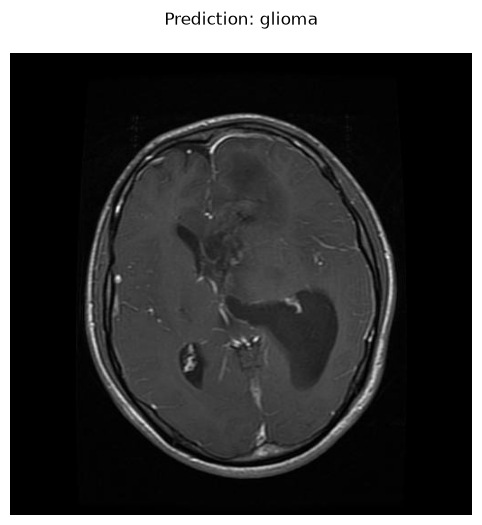

In [47]:
NEW_IMAGE_PATH = (
    PROJECT_ROOT
    / "data"
    / "Epic and CSCR hospital Dataset"
    / "test"
    / "glioma"
    / "1353.jpg"
)


def predict_new_image(
    image_path,
    model,
    transform,
    class_names,
    device,
    confidence_threshold=0.70
):
    image_path = Path(image_path)

    if not image_path.exists():
        raise FileNotFoundError(
            f"Image not found: {image_path.resolve()}"
        )

    with Image.open(image_path) as image:
        original_image = image.convert("RGB")

    input_tensor = (
        transform(original_image)
        .unsqueeze(0)
        .to(device)
    )

    model.eval()

    with torch.no_grad():
        logits = model(input_tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    confidence, predicted_index = torch.max(
        probabilities,
        dim=0
    )

    predicted_index = int(
        predicted_index.item()
    )

    confidence = float(
        confidence.item()
    )

    predicted_class = class_names[
        predicted_index
    ]

    class_probabilities = {
        class_name: float(
            probabilities[class_index].item()
        )
        for class_index, class_name
        in enumerate(class_names)
    }

    requires_review = (
        confidence < confidence_threshold
    )

    return {
        "image_path": str(image_path),
        "predicted_class": predicted_class,
        "confidence": confidence,
        "requires_review": requires_review,
        "class_probabilities": class_probabilities,
        "original_image": original_image
    }


new_prediction = predict_new_image(
    image_path=NEW_IMAGE_PATH,
    model=improved_tuned_model,
    transform=evaluation_transforms,
    class_names=class_names,
    device=device,
    confidence_threshold=CONFIDENCE_THRESHOLD
)

print(
    "Image path:",
    new_prediction["image_path"]
)

print(
    "Predicted class:",
    new_prediction["predicted_class"]
)

print(
    "Confidence:",
    round(
        new_prediction["confidence"],
        4
    )
)

print(
    "Manual review recommended:",
    new_prediction["requires_review"]
)

print("\nClass probabilities:")

sorted_probabilities = sorted(
    new_prediction[
        "class_probabilities"
    ].items(),
    key=lambda item: item[1],
    reverse=True
)

for class_name, probability in sorted_probabilities:
    print(
        f"{class_name}: {probability:.6f}"
    )

plt.figure(figsize=(6, 6))

plt.imshow(
    new_prediction["original_image"]
)

plt.title(
    f"Prediction: "
    f"{new_prediction['predicted_class']}\n"
)

plt.axis("off")
plt.show()